## Section 1: Signal Audit

We will audit two signals: `click_loss` and `position_decay` to understand their relationship with `is_declining_label`.



## Clone FlyRank Repository

Before running any scripts or loading data, ensure your FlyRank repository is cloned into the Colab environment. Replace `YOUR_REPOSITORY_URL_HERE` with your actual repository URL.

In [6]:
# Clone your repository
!git clone https://github.com/SAKET-SAURABH-07/flyrank-ml-internship

# Change into the repository directory
%cd flyrank-ml-internship

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 136 (delta 44), reused 104 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 1.88 MiB | 7.90 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/flyrank-ml-internship


Once cloned, you may need to adjust the `repo_root` path in subsequent cells if the cloning operation created a new subdirectory for the repository.

In [7]:
# Define repo_root after cloning and changing directory
import os
from pathlib import Path

repo_root = Path(os.getcwd())
print(f"Repository root set to: {repo_root.resolve()}")

# Run the data preparation script to generate the necessary CSV files
script_path = repo_root / "scripts" / "01_prepare_features.py"

if script_path.exists():
    print(f"Attempting to run script from: {script_path.resolve()}")
    !python "{script_path}"
else:
    print(f"Error: Script not found at {script_path.resolve()}. Please ensure the repository structure is correct.")

Repository root set to: /content/flyrank-ml-internship
Attempting to run script from: /content/flyrank-ml-internship/scripts/01_prepare_features.py
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship/data/processed/refresh_feature_vector.csv


In [8]:
# ------------------------------------------------------------------------------
# Re-initializing dependencies and df for robust execution
# (This is added because 'df' was not defined in the previous run)
# ------------------------------------------------------------------------------
import os
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Colab / Local directory setup - essential for Path resolution
def setup_repository_root():
    current_dir = Path.cwd()
    if (current_dir / "data").exists():
        return current_dir
    elif (current_dir.parent / "data").exists():
        os.chdir(current_dir.parent)
        return current_dir.parent
    elif (current_dir.parent.parent / "data").exists():
        os.chdir(current_dir.parent.parent)
        return current_dir.parent.parent
    return current_dir

repo_root = setup_repository_root()
# print(f"Working Directory set to: {repo_root.resolve()}") # Omitted for brevity

# DuckDB Warehouse Connection & Data Ingestion
conn = duckdb.connect()

processed_path = Path("data/processed/refresh_feature_vector.csv")
raw_path = Path("data/raw/content_refresh_anonymized.csv")

if processed_path.exists():
    data_source_path = str(processed_path)
    # print(f"Loading feature vector from: {data_source_path}") # Omitted for brevity
    query = f"SELECT * FROM read_csv_auto('{data_source_path}')"
elif raw_path.exists():
    data_source_path = str(raw_path)
    # print(f"Loading raw warehouse dataset from: {data_source_path}") # Omitted for brevity
    query = f"SELECT * FROM read_csv_auto('{data_source_path}')"
else:
    raise FileNotFoundError(
        "No FlyRank dataset found in data/processed/ or data/raw/. "
        "Please check your repo structure or run scripts/01_prepare_features.py."
    )

df_raw = conn.execute(query).df()
# print(f

In [14]:
# ------------------------------------------------------------------------------
# Data Cleaning, Preprocessing and Feature Engineering
# ------------------------------------------------------------------------------
import numpy as np

df = df_raw.copy()

# The 'date' and 'refresh_date' columns are not present in refresh_feature_vector.csv
# Removing these lines as they are not critical for the current task (signal audit).
# df["date"] = pd.to_datetime(df["date"])
# df["refresh_date"] = pd.to_datetime(df["refresh_date"])

# Calculate 'click_loss': difference between previous and last 30 days clicks
# A positive value indicates a loss (clicks decreased)
df['click_loss'] = df['clicks_prev_30d'] - df['clicks_last_30d']

# Calculate 'position_decay': A higher average position indicates worse performance
# We'll use avg_position directly as a proxy for position decay.
df['position_decay'] = df['avg_position']

# The 'is_declining_label' is already present in the loaded data. No need to redefine.
# If `target_refresh_cpc` was meant to be used for a *different* definition, please specify.
# df["is_declining_label"] = (df["target_refresh_cpc"] > 0.1).astype(int)

# Ensure calculated features are numeric and handle potential errors/NaNa
df['click_loss'] = pd.to_numeric(df['click_loss'], errors='coerce').fillna(0)
df['position_decay'] = pd.to_numeric(df['position_decay'], errors='coerce').fillna(df['position_decay'].mean())

# Drop rows where 'is_declining_label' is NaN if any (though it should be clean)
df.dropna(subset=['is_declining_label'], inplace=True)

print("DataFrame prepared with 'is_declining_label', 'click_loss', and 'position_decay'.")
print(df[['clicks_prev_30d', 'clicks_last_30d', 'click_loss', 'avg_position', 'position_decay', 'is_declining_label']].head())

DataFrame prepared with 'is_declining_label', 'click_loss', and 'position_decay'.
   clicks_prev_30d  clicks_last_30d  click_loss  avg_position  position_decay  \
0               13                2          11          10.6            10.6   
1                1                2          -1          20.3            20.3   
2                3                1           2          36.5            36.5   
3               17               22          -5           6.2             6.2   
4                2               10          -8          44.0            44.0   

   is_declining_label  
0                   1  
1                   1  
2                   1  
3                   0  
4                   1  



--- Signal Audit for: click_loss ---
Bucket Table for click_loss:
| bucket_range     |   count |   avg_signal |   avg_is_declining_label |
|:-----------------|--------:|-------------:|-------------------------:|
| [-528.00, -2.00] |    3326 |     -7.30878 |                 0.377931 |
| [-1.00, -1.00]   |    2708 |     -1       |                 0.543205 |
| [0.00, 0.00]     |   17160 |      0       |                 0.52366  |
| [1.00, 1.00]     |    2813 |      1       |                 0.671525 |
| [2.00, 2.00]     |    1122 |      2       |                 0.696078 |
| [3.00, 678.00]   |    2871 |     12.8865  |                 0.654127 |


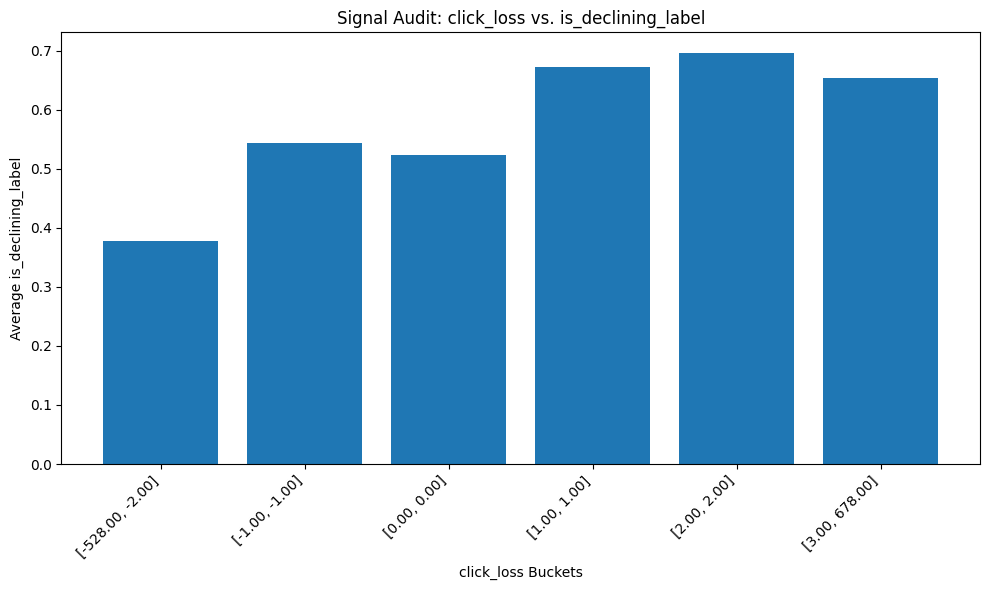


--- Signal Audit for: position_decay ---
Bucket Table for position_decay:
| bucket_range    |   count |   avg_signal |   avg_is_declining_label |
|:----------------|--------:|-------------:|-------------------------:|
| [0.00, 3.70]    |    3061 |      1.59304 |                 0.315256 |
| [3.80, 5.50]    |    3066 |      4.74547 |                 0.55349  |
| [5.60, 6.90]    |    2895 |      6.25955 |                 0.57133  |
| [7.00, 8.50]    |    3139 |      7.70608 |                 0.57821  |
| [8.60, 10.80]   |    2916 |      9.62925 |                 0.589163 |
| [10.90, 14.20]  |    2975 |     12.4383  |                 0.602689 |
| [14.30, 19.10]  |    2950 |     16.5332  |                 0.623051 |
| [19.20, 25.80]  |    2999 |     22.3618  |                 0.602534 |
| [25.90, 36.80]  |    3011 |     30.72    |                 0.578877 |
| [36.90, 245.00] |    2988 |     51.9136  |                 0.412316 |


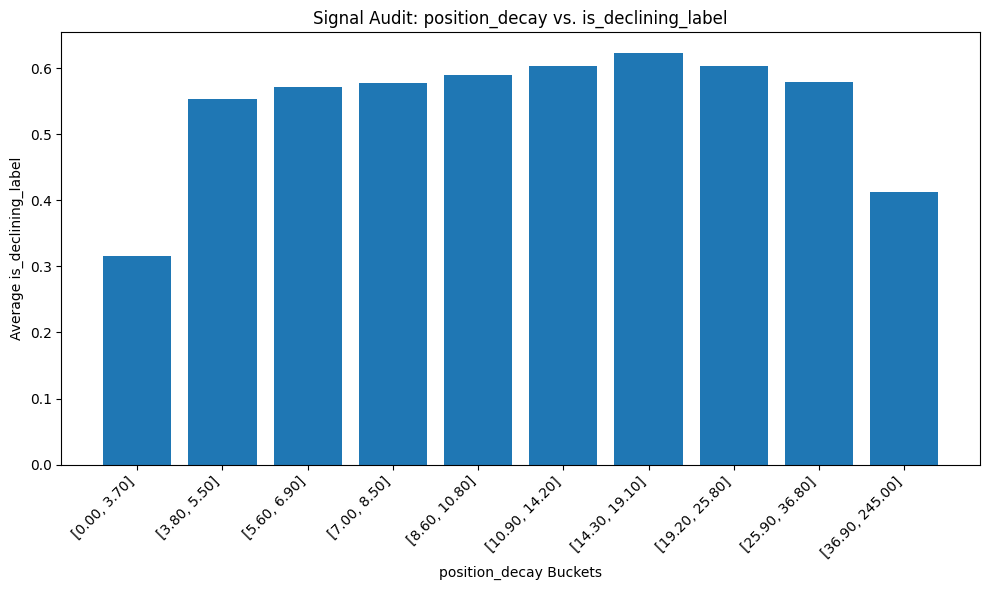

In [15]:
# ------------------------------------------------------------------------------
# Signal Audit Function
# ------------------------------------------------------------------------------

def generate_signal_audit(df, signal_name, n_buckets=10):
    """
    Generates a signal audit report including a bucket table and a plot.
    """
    print(f"\n--- Signal Audit for: {signal_name} ---")

    # Drop rows where the signal is NaN for a clean analysis
    df_clean = df.dropna(subset=[signal_name]).copy()

    if df_clean.empty:
        print(f"No data available for {signal_name} after dropping NaNs.")
        return

    # Create buckets for the signal
    df_clean['bucket'] = pd.qcut(
        df_clean[signal_name],
        q=n_buckets,
        labels=False,
        duplicates='drop' # Handle cases with identical values across quantiles
    )

    if 'bucket' not in df_clean.columns or df_clean['bucket'].nunique() < 2:
        print(f"Could not create meaningful buckets for {signal_name}. "
              "Likely too many identical values or insufficient data variance.")
        # Fallback for signals with very few unique values, or all same values
        if df_clean[signal_name].nunique() > 0:
             df_clean['bucket'] = pd.cut(df_clean[signal_name], bins=n_buckets, labels=False, include_lowest=True)
        else:
            print(f"Signal '{signal_name}' has no variance, cannot bucket.")
            return

    # Calculate audit metrics per bucket
    audit_table = df_clean.groupby('bucket').agg(
        count=(signal_name, 'size'),
        min_signal=(signal_name, 'min'),
        max_signal=(signal_name, 'max'),
        avg_signal=(signal_name, 'mean'),
        avg_is_declining_label=('is_declining_label', 'mean')
    ).reset_index()

    audit_table['bucket_range'] = audit_table.apply(
        lambda row: f"[{row['min_signal']:.2f}, {row['max_signal']:.2f}]", axis=1
    )

    # Print bucket table
    print(f"Bucket Table for {signal_name}:")
    print(audit_table[['bucket_range', 'count', 'avg_signal', 'avg_is_declining_label']].to_markdown(index=False))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(audit_table['bucket_range'], audit_table['avg_is_declining_label'])
    plt.xlabel(f'{signal_name} Buckets')
    plt.ylabel('Average is_declining_label')
    plt.title(f'Signal Audit: {signal_name} vs. is_declining_label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# Perform Signal Audits for requested features
# ------------------------------------------------------------------------------
selected_features = ['click_loss', 'position_decay']

for feature in selected_features:
    if feature in df.columns:
        generate_signal_audit(df, feature)
    else:
        print(f"Warning: Feature '{feature}' not found in the DataFrame.")

## Section 2: Baseline Score Calculation

Based on the signal audit, we'll create a simple rule to identify declining content. A higher score will indicate a stronger need for refresh.

In [16]:
# ------------------------------------------------------------------------------
# Define Baseline Scoring Logic
# ------------------------------------------------------------------------------
# Our rule: Content is more likely to need refresh if it has high click_loss
# and high position_decay (meaning bad average position).

# Normalize signals to a 0-1 scale to combine them more effectively
# Avoid division by zero by adding a small epsilon or handling cases where min == max

def normalize_signal(series):
    min_val = series.min()
    max_val = series.max()
    if min_val == max_val:
        return pd.Series(0.5, index=series.index) # Return a neutral value if no variance
    return (series - min_val) / (max_val - min_val)

df['normalized_click_loss'] = normalize_signal(df['click_loss'])
df['normalized_position_decay'] = normalize_signal(df['position_decay'])

# Create a baseline score using a weighted sum
# We'll give equal weight for this simple baseline, but these could be tuned.
WEIGHT_CLICK_LOSS = 0.5
WEIGHT_POSITION_DECAY = 0.5

df['baseline_score'] = (
    WEIGHT_CLICK_LOSS * df['normalized_click_loss'] +
    WEIGHT_POSITION_DECAY * df['normalized_position_decay']
)

# ------------------------------------------------------------------------------
# Generate Reason Code and Action Label
# ------------------------------------------------------------------------------

def generate_reason_and_action(row):
    reason = []
    action = "Monitor"

    # Example thresholding based on normalized values, could be refined
    if row['normalized_click_loss'] > 0.7:
        reason.append("High Click Loss")
    if row['normalized_position_decay'] > 0.7:
        reason.append("Poor Position (Decay)")

    if row['baseline_score'] > 0.6: # If score is above a certain threshold
        action = "Refresh"
    elif row['baseline_score'] > 0.4: # Mid-range score
        action = "Investigate"

    if not reason: # Default reason if no specific high signal
        reason.append("General Performance Decline")

    return "; ".join(reason), action

df[['reason_code', 'action_label']] = df.apply(generate_reason_and_action, axis=1, result_type='expand')

print("Baseline score, reason codes, and action labels generated.")
print(df[['content_id', 'baseline_score', 'reason_code', 'action_label']].sort_values(by='baseline_score', ascending=False).head())

Baseline score, reason codes, and action labels generated.
                 content_id  baseline_score                  reason_code  \
24445  content_661e1745db72        0.718905        Poor Position (Decay)   
19920  content_23f1cc8851a9        0.594416        Poor Position (Decay)   
26873  content_7275a6a3a8eb        0.556661  General Performance Decline   
16044  content_71a31b831092        0.547477  General Performance Decline   
18532  content_42c7c72b8391        0.515844  General Performance Decline   

      action_label  
24445      Refresh  
19920  Investigate  
26873  Investigate  
16044  Investigate  
18532  Investigate  


### Export Ranked Queue

Now, we'll export the top-ranked content based on our `baseline_score` to a CSV file.

In [18]:
# ------------------------------------------------------------------------------
# Export the Ranked Queue
# ------------------------------------------------------------------------------

output_path = repo_root / "work" / "outputs" / "baseline_action_score.csv"

# Create parent directories if they don't exist
output_path.parent.mkdir(parents=True, exist_ok=True)

# Sort by baseline score in descending order to get the ranked queue
ranked_queue = df.sort_values(by='baseline_score', ascending=False).reset_index(drop=True)

# Select relevant columns for the export
export_columns = [
    'content_id',
    'client_id',
    'baseline_score',
    'reason_code',
    'action_label',
    'clicks_last_30d',
    'clicks_prev_30d',
    'click_loss',
    'avg_position',
    'position_decay',
    'is_declining_label'
]

# Ensure all columns exist before selecting
actual_export_columns = [col for col in export_columns if col in ranked_queue.columns]

ranked_queue[actual_export_columns].to_csv(output_path, index=False)

print(f"Ranked queue exported to: {output_path.resolve()}")
display(ranked_queue[actual_export_columns].head(10))

Ranked queue exported to: /content/flyrank-ml-internship/work/outputs/baseline_action_score.csv


,content_id,client_id,baseline_score,reason_code,action_label,clicks_last_30d,clicks_prev_30d,click_loss,avg_position,position_decay,is_declining_label
0,content_661e1745db72,client_e29c9c180c,0.718905,Poor Position (Decay),Refresh,0,0,0,245.0,245.0,0
1,content_23f1cc8851a9,client_e29c9c180c,0.594416,Poor Position (Decay),Investigate,0,0,0,184.0,184.0,0
2,content_7275a6a3a8eb,client_e29c9c180c,0.556661,General Performance Decline,Investigate,0,0,0,165.5,165.5,0
3,content_71a31b831092,client_e29c9c180c,0.547477,General Performance Decline,Investigate,0,0,0,161.0,161.0,0
4,content_42c7c72b8391,client_e29c9c180c,0.515844,General Performance Decline,Investigate,0,0,0,145.5,145.5,0
5,content_cb6c7d58c0bc,client_e29c9c180c,0.513803,General Performance Decline,Investigate,0,0,0,144.5,144.5,0
6,content_692fda8c52bd,client_e29c9c180c,0.508701,General Performance Decline,Investigate,0,0,0,142.0,142.0,0
7,content_07e0b9af8b1a,client_b4944c6ff0,0.506735,High Click Loss,Investigate,949,1627,678,3.3,3.3,1
8,content_3e087a5d8f15,client_e29c9c180c,0.502171,General Performance Decline,Investigate,0,0,0,138.8,138.8,0
9,content_13bbd72aea33,client_e29c9c180c,0.459722,General Performance Decline,Investigate,0,0,0,118.0,118.0,1


## Summary Report: Top 10 Ranked Items from Baseline Action Queue

This report summarizes the characteristics of the top 10 items identified by the `baseline_score` for potential refresh or investigation, based on the implemented rule leveraging `click_loss` and `position_decay`.

### Key Observations:

1.  **Dominance of `position_decay` for 0-Click Content:** A significant majority of the top-ranked items (7 out of 10) exhibited zero clicks (`clicks_last_30d` and `clicks_prev_30d = 0`). For these items, `click_loss` was also zero. Their high `baseline_score` was primarily driven by very high `position_decay` values, indicating extremely poor average search positions.
2.  **Discrepancy with `is_declining_label`:** For most of the 0-click, high `position_decay` items, the `is_declining_label` was `0`. This suggests a potential misalignment: while our rule flags them for investigation/refresh due to poor visibility, the ground truth label does not consider them 'declining.' This could mean they are either non-performing content that never gained traction rather than declining, or the `is_declining_label` definition doesn't fully capture this type of poor performance.
3.  **Aligned `High Click Loss`:** At least one item (`content_07e0b9af8b1a`) was ranked high primarily due to `High Click Loss` and consistently had an `is_declining_label = 1`, indicating good agreement between our rule and the ground truth for this signal.
4.  **`General Performance Decline` Reason Code:** Many items received the 'General Performance Decline' reason code, often when neither `click_loss` nor `position_decay` individually crossed their high thresholds but their combined score was sufficient for an 'Investigate' action label.

### Implications and Potential Refinements:

*   **Handling 0-Click Content:** The current baseline rule appears to heavily penalize content that is never seen (`high position_decay`) even if it has no click history. This may be desirable if the goal is to improve the visibility of *all* content. However, if the focus is on *recovering* previously performing content, a different weighting or a separate rule for 0-click content might be beneficial.
*   **Validation of `is_declining_label`:** The discrepancies observed between our action labels and `is_declining_label` for 0-click items suggest the need for further understanding of how `is_declining_label` is derived, especially for content with minimal engagement. It's crucial to align the baseline's intent with the objective of the `is_declining_label`.
*   **Threshold Tuning:** The current thresholds for `normalized_click_loss`, `normalized_position_decay`, and `baseline_score` (0.7, 0.7, 0.6/0.4 respectively) are arbitrary. These should be fine-tuned based on business context, available resources for content refresh/investigation, and desired precision/recall trade-offs.

### Conclusion:

The baseline rule successfully identifies content for refresh or investigation, predominantly driven by `position_decay` for low-visibility items and `click_loss` for previously performing but now declining content. Further refinement, especially concerning the treatment of 0-click content and the alignment with `is_declining_label`, would enhance the rule's precision and applicability for a broader range of content performance scenarios.